### Model 2: Traffic Accident Severity — Deep Neural Network

- Same prediction task as Model 1, but using a deep learning approach
- The same class imbalance challenge applies — evaluate with weighted F1
- Build a neural network (TensorFlow/Keras) on the tabular accident data
- Compare performance against your traditional ML model
- **Minimum Benchmark:** Accuracy > 70%, weighted F1 > 0.55
- **Stretch Goal:** Accuracy > 82%, weighted F1 > 0.72
- **Required:** Show how DNN performance compares to traditional ML and explain the trade-offs

Build Deep Learning Model using Google Colab due to GPU limit on local machine

In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [76]:
# Required imports - run this cell first!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

# Model saving
import joblib

# Settings
plt.style.use('seaborn-v0_8-whitegrid')

pd.set_option('display.max_columns', None)
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [55]:
# Load cleaned data
# df = pd.read_csv('../data/processed/cleaned_data.csv')
df = pd.read_csv('/content/drive/MyDrive/cleaned_data/cleaned_data.csv')
print(f"Data shape: {df.shape}")
df.head()

Data shape: (499290, 257)


,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),City,County,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Target,hour,day_of_week,month,is_weekend,is_morning_rush,is_evening_rush,is_rush_hour,duration_min,is_freezing,low_visibility,lat_bin,n_road_features,has_traffic_control,State_al,State_ar,State_az,State_ca,State_co,State_ct,State_dc,State_de,State_fl,State_ga,State_ia,State_id,State_il,State_in,State_ks,State_ky,State_la,State_ma,State_md,State_me,State_mi,State_mn,State_mo,State_ms,State_mt,State_nc,State_nd,State_ne,State_nh,State_nj,State_nm,State_nv,State_ny,State_oh,State_ok,State_or,State_pa,State_ri,State_sc,State_sd,State_tn,State_tx,State_ut,State_va,State_vt,State_wa,State_wi,State_wv,State_wy,State_nan,Timezone_missing,Timezone_us/central,Timezone_us/eastern,Timezone_us/mountain,Timezone_us/pacific,Timezone_nan,Wind_Direction_calm,Wind_Direction_e,Wind_Direction_east,Wind_Direction_ene,Wind_Direction_ese,Wind_Direction_missing,Wind_Direction_n,Wind_Direction_ne,Wind_Direction_nne,Wind_Direction_nnw,Wind_Direction_north,Wind_Direction_nw,Wind_Direction_s,Wind_Direction_se,Wind_Direction_south,Wind_Direction_sse,Wind_Direction_ssw,Wind_Direction_sw,Wind_Direction_var,Wind_Direction_variable,Wind_Direction_w,Wind_Direction_west,Wind_Direction_wnw,Wind_Direction_wsw,Wind_Direction_nan,Weather_Condition_blowing dust,Weather_Condition_blowing dust / windy,Weather_Condition_blowing snow,Weather_Condition_blowing snow / windy,Weather_Condition_clear,Weather_Condition_cloudy,Weather_Condition_cloudy / windy,Weather_Condition_drifting snow / windy,Weather_Condition_drizzle,Weather_Condition_drizzle / windy,Weather_Condition_drizzle and fog,Weather_Condition_duststorm,Weather_Condition_fair,Weather_Condition_fair / windy,Weather_Condition_fog,Weather_Condition_fog / windy,Weather_Condition_freezing drizzle,Weather_Condition_freezing rain,Weather_Condition_hail,Weather_Condition_haze,Weather_Condition_haze / windy,Weather_Condition_heavy drizzle,Weather_Condition_heavy freezing drizzle,Weather_Condition_heavy rain,Weather_Condition_heavy rain / windy,Weather_Condition_heavy sleet,Weather_Condition_heavy snow,Weather_Condition_heavy snow / windy,Weather_Condition_heavy t-storm,Weather_Condition_heavy t-storm / windy,Weather_Condition_heavy thunderstorms and rain,Weather_Condition_ice pellets,Weather_Condition_light drizzle,Weather_Condition_light drizzle / windy,Weather_Condition_light freezing drizzle,Weather_Condition_light freezing fog,Weather_Condition_light freezing rain,Weather_Condition_light freezing rain / windy,Weather_Condition_light ice pellets,Weather_Condition_light rain,Weather_Condition_light rain / windy,Weather_Condition_light rain shower,Weather_Condition_light rain shower / windy,Weather_Condition_light rain showers,Weather_Condition_light rain with thunder,Weather_Condition_light sleet,Weather_Condition_light sleet / windy,Weather_Condition_light snow,Weather_Condition_light snow / windy,Weather_Condition_light snow and sleet,Weather_Condition_light snow and sleet / windy,Weather_Condition_light snow grains,Weather_Condition_light snow shower,Weather_Condition_light snow showers,Weather_Condition_light snow with thunder,Weather_Condition_light thunderstorms and rain,Weather_Condition_light thunderstorms and snow,Weather_Condition_missing,Weather_Condition_mist,Weather_Condition_mist / windy,Weather_Condition_mostly cloudy,Weather_Condition_mostly cloudy / windy,Weather_Condition_n/a precipitation,Weather_Condition_overcast,Weather_Condition_partial fog,Weather_Condition_partly cloudy,Weather_Condition_partly cloudy / windy,Weather_Condition_patches of fog,Weather_Condition_patches of fog / windy,Weather_Condition_rain,Weather_Condition_rain / windy,Weather_Condition_rain shower,Wea

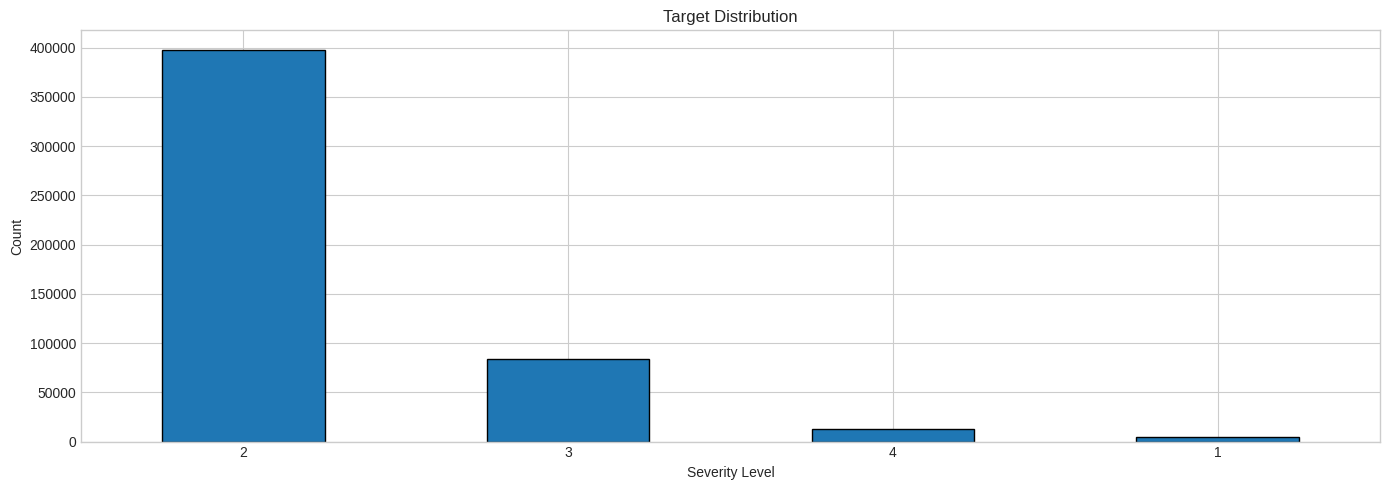

In [56]:
# Visualize the binned distribution
fig, ax = plt.subplots(1, 1, figsize=(14, 5))

# Binned category counts
df['Target'].value_counts().plot(kind='bar', ax=ax, edgecolor='black')
ax.set_xlabel('Severity Level')
ax.set_ylabel('Count')
ax.set_title('Target Distribution')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [57]:
# Check class balance
class_counts = df['Target'].value_counts()
class_percentages = df['Target'].value_counts(normalize=True) * 100

print("Class Distribution:")
for cat in class_counts.index:
    print(f"{cat}: {class_counts[cat]} ({class_percentages[cat]:.1f}%)")

# Check for severe imbalance
min_class_pct = class_percentages.min()
if min_class_pct < 10:
    print(f"\nWarning: Smallest class is only {min_class_pct:.1f}% of data.")
    print("Consider adjusting your binning strategy.")
else:
    print(f"\nClass balance looks reasonable!")

Class Distribution:
2: 397669 (79.6%)
3: 84039 (16.8%)
4: 13229 (2.6%)
1: 4353 (0.9%)

Consider adjusting your binning strategy.


In [58]:
X = df.drop(columns=['Severity', 'Target', 'Start_Time', 'End_Time', 'Weather_Timestamp']).copy()
y = df['Target']

In [59]:
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used: {X.columns.tolist()}")
print(f"\nTarget classes: {y.unique().tolist()}")

Features shape: (499290, 252)
Target shape: (499290,)

Features used: ['Start_Lat', 'Start_Lng', 'Distance(mi)', 'City', 'County', 'Airport_Code', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_morning_rush', 'is_evening_rush', 'is_rush_hour', 'duration_min', 'is_freezing', 'low_visibility', 'lat_bin', 'n_road_features', 'has_traffic_control', 'State_al', 'State_ar', 'State_az', 'State_ca', 'State_co', 'State_ct', 'State_dc', 'State_de', 'State_fl', 'State_ga', 'State_ia', 'State_id', 'State_il', 'State_in', 'State_ks', 'State_ky', 'State_la', 'State_ma', 'State_md', 'State_me', 'State_mi', 'State_mn', 'State_mo', 'State_ms', 'State_mt', 'State_nc', 'State_nd', 'State_ne', 'State_nh', 'State_nj', 'Sta

In [60]:
# -----------------------------
# 1. Split data
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# 2. Scale numeric features
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [115]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

print("Original classes:", label_encoder.classes_)
print("Encoded train classes:", np.unique(y_train_enc))
print("Encoded test classes:", np.unique(y_test_enc))

Original classes: [1 2 3 4]
Encoded train classes: [0 1 2 3]
Encoded test classes: [0 1 2 3]


In [89]:
'''
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_enc)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_enc
)

class_weights = dict(zip(classes, weights))
print("Class weights:")
for k,v in class_weights.items():
    print(f"{k}: {v:.2f}")
    '''

# Above fully balanced class weights improved Recall scores for level 3 and level 4 incidents.
# But it is dragging down overall accuracy due to level 2 is the majority class
# use a manual class weight to re-train the model

class_weights = {
    0: 2.0,   # class 1
    1: 1.0,   # class 2
    2: 1.5,   # class 3
    3: 2.0    # class 4
}


In [90]:
# Verify split and stratification
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTraining class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f" {c} ({c/len(y_train)*100:.1f}%)")

Training set: 399432 samples
Test set: 99858 samples

Training class distribution:
 3483 (0.9%)
 318135 (79.6%)
 67231 (16.8%)
 10583 (2.6%)


In [91]:
SELECTED_FEATURES = X.columns.tolist()
print("Features scaled successfully!")
print(f"Scaler fitted on {len(SELECTED_FEATURES)} features.")

Features scaled successfully!
Scaler fitted on 252 features.


In [92]:
from tensorflow import keras
from tensorflow.keras import layers

In [93]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.backend.clear_session()

nn_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(4, activation="softmax")
])

nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [94]:
history = nn_model.fit(
    X_train_scaled,
    y_train_enc,
    validation_split=0.2,
    epochs=50,
    batch_size=1024,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7316 - loss: 0.9548 - val_accuracy: 0.7953 - val_loss: 0.5569
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.7858 - loss: 0.7734 - val_accuracy: 0.7964 - val_loss: 0.5299
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7918 - loss: 0.7388 - val_accuracy: 0.8018 - val_loss: 0.5153
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.7955 - loss: 0.7161 - val_accuracy: 0.8054 - val_loss: 0.5054
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7984 - loss: 0.7009 - val_accuracy: 0.8087 - val_loss: 0.4986
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8002 - loss: 0.6897 - val_accuracy: 0.8112 - val_loss: 0.4896
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.8022 - loss: 0.6781 - val_accuracy: 0.8123 - val_loss: 0.4839
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8040 - loss: 0.6694 - val_accu

In [95]:
def plot_training_curves(history):
    """
    Plot training and validation loss/accuracy curves.

    Creates two side-by-side subplots:
    - Left: Training vs Validation Loss
    - Right: Training vs Validation Accuracy

    Args:
        history: Keras training history object
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Loss
    ax1.plot(history.history['loss'], label='Training Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Plot Accuracy
    ax2.plot(history.history['accuracy'], label='Training Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

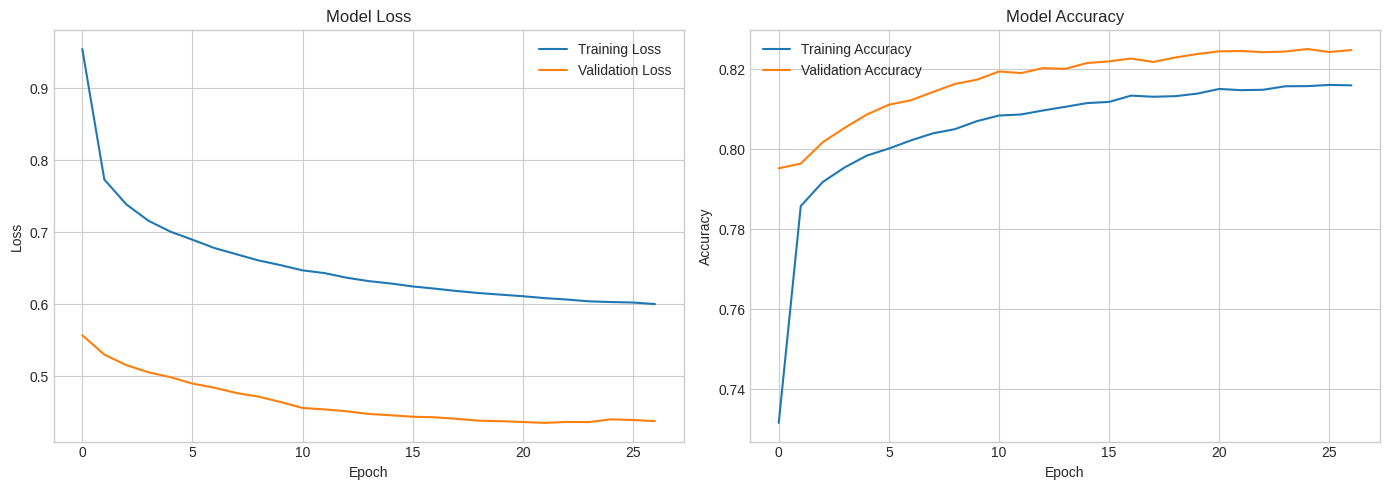

In [96]:
plot_training_curves(history)

In [128]:
y_train_pred_proba = nn_model.predict(X_train_scaled)

p0 = y_train_pred_proba[:, 0]   # class 1
p1 = y_train_pred_proba[:, 1]   # class 2
p2 = y_train_pred_proba[:, 2]   # class 3
p3 = y_train_pred_proba[:, 3]   # class 4

y_train_pred_adj = []

for i in range(len(y_train_pred_proba)):
    # favor class 1 if probability clears a lower custom threshold
    if p0[i] >= 0.30:
        y_train_pred_adj.append(0)
    # favor class 4 if strong enough
    elif p3[i] >= 0.40:
        y_train_pred_adj.append(3)
    else:
        y_train_pred_adj.append(np.argmax(y_train_pred_proba[i]))

y_train_pred_adj = np.array(y_train_pred_adj)

12483/12483 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step


In [129]:
y_pred_proba = nn_model.predict(X_test_scaled)

p0 = y_pred_proba[:, 0]   # class 1
p1 = y_pred_proba[:, 1]   # class 2
p2 = y_pred_proba[:, 2]   # class 3
p3 = y_pred_proba[:, 3]   # class 4

y_pred_adj = []

for i in range(len(y_pred_proba)):
    # favor class 1 if probability clears a lower custom threshold
    if p0[i] >= 0.30:
        y_pred_adj.append(0)
    # favor class 4 if strong enough
    elif p3[i] >= 0.40:
        y_pred_adj.append(3)
    else:
        y_pred_adj.append(np.argmax(y_pred_proba[i]))

y_pred_adj = np.array(y_pred_adj)

3121/3121 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


In [136]:
'''
find the best prediction threshhold

import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

def adjust_predictions(proba, th0=0.12, th3=0.20):
    preds = []
    for p in proba:
        if p[0] >= th0:
            preds.append(0)   # class 1
        elif p[3] >= th3:
            preds.append(3)   # class 4
        else:
            preds.append(np.argmax(p))
    return np.array(preds)

best = None

for th0 in [0.20, 0.22, 0.24, 0.26, 0.28, 0.30]:
    for th3 in [0.25, 0.30, 0.35, 0.40]:
        y_pred_adj = adjust_predictions(y_pred_proba, th0=th0, th3=th3)
        acc = accuracy_score(y_test_enc, y_pred_adj)
        wf1 = f1_score(y_test_enc, y_pred_adj, average="weighted")

        print(f"th0={th0:.2f}, th3={th3:.2f}, acc={acc:.4f}, weighted_f1={wf1:.4f}")

        if best is None or (acc > best[0] and wf1 > 0.72):
            best = (acc, wf1, th0, th3)

print("Best:", best)
'''

'\nfind the best prediction threshhold\n\nimport numpy as np\nfrom sklearn.metrics import accuracy_score, f1_score, classification_report\n\ndef adjust_predictions(proba, th0=0.12, th3=0.20):\n    preds = []\n    for p in proba:\n        if p[0] >= th0:\n            preds.append(0)   # class 1\n        elif p[3] >= th3:\n            preds.append(3)   # class 4\n        else:\n            preds.append(np.argmax(p))\n    return np.array(preds)\n\nbest = None\n\nfor th0 in [0.20, 0.22, 0.24, 0.26, 0.28, 0.30]:\n    for th3 in [0.25, 0.30, 0.35, 0.40]:\n        y_pred_adj = adjust_predictions(y_pred_proba, th0=th0, th3=th3)\n        acc = accuracy_score(y_test_enc, y_pred_adj)\n        wf1 = f1_score(y_test_enc, y_pred_adj, average="weighted")\n        \n        print(f"th0={th0:.2f}, th3={th3:.2f}, acc={acc:.4f}, weighted_f1={wf1:.4f}")\n        \n        if best is None or (acc > best[0] and wf1 > 0.72):\n            best = (acc, wf1, th0, th3)\n\nprint("Best:", best)\n'

In [130]:
y_train_pred = y_train_pred_adj
y_test_pred = y_pred_adj

In [131]:
print (f"'Train Accuracy': {accuracy_score(y_train_enc, y_train_pred):.4f}")

'Train Accuracy': 0.8265


In [132]:
print (f"'Test Accuracy': {accuracy_score(y_test_enc, y_test_pred):.4f}")

'Test Accuracy': 0.8250


In [133]:
print (f"'Precision (weighted)': {precision_score(y_test_enc, y_test_pred, average='weighted'):.4f}")

'Precision (weighted)': 0.8070


In [134]:
print (f"'Recall (weighted)': {recall_score(y_test_enc, y_test_pred, average='weighted'):.4f}")

'Recall (weighted)': 0.8250


In [135]:
print (f"'F1 (weighted)': {f1_score(y_test_enc, y_test_pred, average='weighted'):.4f}")

'F1 (weighted)': 0.8106


In [137]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test_enc, y_pred_adj, target_names=["1", "2", "3", "4"]))
print(confusion_matrix(y_test_enc, y_pred_adj))

              precision    recall  f1-score   support

           1       0.41      0.07      0.12       870
           2       0.87      0.93      0.90     79534
           3       0.59      0.49      0.54     16808
           4       0.50      0.13      0.20      2646

    accuracy                           0.83     99858
   macro avg       0.59      0.40      0.44     99858
weighted avg       0.81      0.83      0.81     99858

[[   61   739    70     0]
 [   84 73671  5573   206]
 [    3  8360  8318   127]
 [    0  2110   203   333]]


Below is the classification report and confusion matrics of the traditional ML model performance

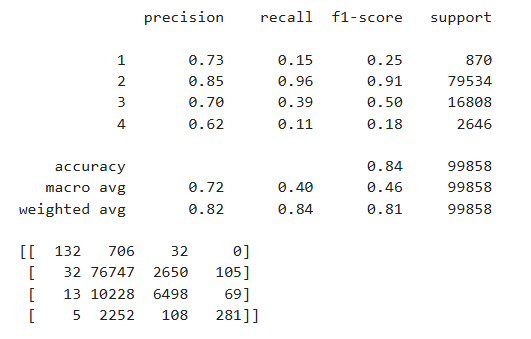

Comparing Tradiotional ML (XGBoost) model to the Deep Learning model we just built and trained:


# ***Overall performance***
________________________________________
XGBoost (Traditional ML)

*   Accuracy	0.84
*   Weighted F1	0.81

DNN (Keras)

*   Accuracy	0.83
*   Weighted 0.81

**Conclusion:**

Very similar overall performance.
XGBoost has a slight edge in accuracy



***Class-level performance***
________________________________________


Class 1 (level 1 severity accidents, 870 rows)

XGBoost --- Recall 0.15 / Precision 0.73

DNN --- Recall 0.07 / Precision 0.41

**Conclusion:**

XGBoost is clearly better.
DNN almost misses class 1 entirely
________________________________________

Class 2 (level 2 severity accidents, 79k rows)

XGBoost --- Recall 0.96 / Precision 0.85

DNN --- Recall 0.93 / Precision 0.87


**Conclusion:**
XGBoost had better recall. DNN had slightly better precision

________________________________________

Class 3 (level 3 severity accidents, 16k rows)

XGBoost --- Recall 0.39 / F1 0.50

DNN --- Recall 0.49 / F1 0.54


**Conclusion:**
DNN wins here. It had better balance between precision & recall

________________________________________

Class 4 (level 4 severity accidents, 2.6k rows)

XGBoost --- Recall 0.11 / F1 0.18

DNN --- Recall 0.13 / F1 0.20


**Conclusion:**
Both are pretty weak. DNN had a sligh edge over XGBoost.

________________________________________
***Insights and Trade-Offs***

XGBoost provides stronger baseline for tabular data - Higher accuracy with more stable decision boundaries


DNN is better at capturing complex patterns. It improved performance on class 3 and class 4. It learns nonlinear interactions across many features (we used 255 features)


**Trade-off is very clear**

XGBoost	has better accuracy and minority precision but misses some mid/rare signals

DNN	is better at minority detection (3 & 4)	but struggles with extreme imbalance (class 1)

Therefore:
If the goal is to achieve highest accuracy then use XGBoost
If the goal is to perform better at minority detection then use DNN



Given that we want to improve detection of major traffic delayes (class 3 and 4), using Deep Learning is a better choice.



